In [1]:
!nvidia-smi

Wed Aug 12 20:33:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    On  |   00000000:01:00.0 Off |                    0 |
| 30%   36C    P8             28W /  300W |       2MiB /  46068MiB |      0%   E. Process |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%pwd

'/projectnb/batmanlab/mragoza/lung-project/notebooks/copdgene'

In [3]:
import sys, os
sys.path.append(os.environ['LP_ROOT'])
import project
from project.core.utils import pprint

# Gather examples

In [4]:
from pathlib import Path
#data_root = Path(os.environ['LP_ROOT'] / 'data' / 'COPDGene'
data_root = Path(os.environ['PRIVATE']) / 'data' / 'COPDGene'
for p in data_root.iterdir():
    print(p)

/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/sample1000_2025-07-22.txt
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/sample1000_2025-07-22.csv
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/subject_files.txt
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Images
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/sample1000_2025-07-17.csv
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/DISK_USAGE
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/ClinicalData


In [5]:
import pandas as pd
subject_file = data_root / 'sample1000_2025-07-22.csv'
subject_list = list(pd.read_csv(subject_file, sep='\t').sid)
pprint(subject_list)

list(len=1000)
├── 0: '16514P'
├── 1: '20748Q'
├── 2: '11007Z'
├── 3: '14771Z'
├── 4: '13651K'
├── 5: '15900P'
├── 6: '15312Y'
├── 7: '21042H'
├── 8: '21877G'
├── 9: '10127E'
└── <990 more items>


In [6]:
%pwd

'/projectnb/batmanlab/mragoza/lung-project/notebooks/copdgene'

In [18]:
config = project.core.fileio.load_config('2026-08-08_config.yaml').copy()
config['dataset']['root'] = str(data_root)
config['dataset']['examples']['subjects'] = subject_list
config['dataset']

Loading 2026-08-08_config.yaml


{'name': 'COPDGene',
 'root': '/restricted/projectnb/batmanlab/mragoza/data/COPDGene',
 'examples': {'subjects': ['16514P',
   '20748Q',
   '11007Z',
   '14771Z',
   '13651K',
   '15900P',
   '15312Y',
   '21042H',
   '21877G',
   '10127E',
   '23577E',
   '13816Q',
   '21559S',
   '25335Q',
   '23023N',
   '10572Z',
   '10887Y',
   '21410K',
   '17920F',
   '14684E',
   '16132B',
   '17862R',
   '11746L',
   '25728J',
   '20609C',
   '16637F',
   '13297S',
   '25767T',
   '25695U',
   '21572K',
   '15078Q',
   '15297C',
   '14857J',
   '13460D',
   '18840M',
   '12506W',
   '11498S',
   '21611U',
   '15088T',
   '12831H',
   '19612E',
   '19784H',
   '10217F',
   '23037Y',
   '25130Y',
   '15623P',
   '19027T',
   '14380K',
   '10212V',
   '16060C',
   '19356M',
   '22357L',
   '25923H',
   '21189L',
   '24608U',
   '15204V',
   '11743F',
   '11879E',
   '12477P',
   '10815Z',
   '17790S',
   '15489L',
   '11850G',
   '13034M',
   '17255W',
   '14632L',
   '26066U',
   '18184E',
   '1

In [17]:
examples = project.api.get_examples(config['dataset'])
len(examples)

Gathering examples


2000

# Visualize source images

In [20]:
# select example
ex = examples[11]
pprint(ex, max_depth=2)

Example()
├── dataset:  'COPDGene'
├── subject:  '15900P'
├── variant:  '2026-08-08'
├── paths:    dict(len=13)
|   ├── 'ref_state':       dict(len=2)
|   ├── 'init_state':      dict(len=5)
|   ├── 'curr_state':      dict(len=5)
|   ├── 'anatomical_map':  PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/15900P/masks/15900P_INSP_iso_tsvf_lung.nii.gz')
|   ├── 'anatomical_mesh': PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/15900P/meshes/15900P_INSP_iso_tsvf_lung_pyg.xdmf')
|   ├── 'material_map':    PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/15900P/fields/15900P_INSP_iso_tsvf_bela_label.nii.gz')
|   ├── 'material_dir':    PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/15900P/fields/15900P_INSP_iso_tsvf_bela')
|   ├── 'disp_field':      PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/15900P/fie

In [21]:
import numpy as np

# load source images
img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['source_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['source_image'])

spacing0 = tuple(float(d) for d in img0.affine[:3,:3] @ np.ones(3))
spacing1 = tuple(float(d) for d in img1.affine[:3,:3] @ np.ones(3))

print(spacing0)
print(spacing1)
print(img0.affine)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Images/15900P/Phase-1/RAW/15900P_INSP_STD_NJC_COPD.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Images/15900P/Phase-1/RAW/15900P_EXP_STD_NJC_COPD.nii.gz
(-0.625, 0.625, 0.5)
(-0.625, 0.625, 0.5)
[[-6.25000000e-01 -0.00000000e+00  0.00000000e+00  1.59687500e+02]
 [ 0.00000000e+00  6.25000000e-01  0.00000000e+00  9.65249634e+00]
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-01  1.02600000e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [22]:
import project.visual.matplotlib as mpl_viz
img_kws = dict(cmap='gray', vmin=-1000, vmax=-500)

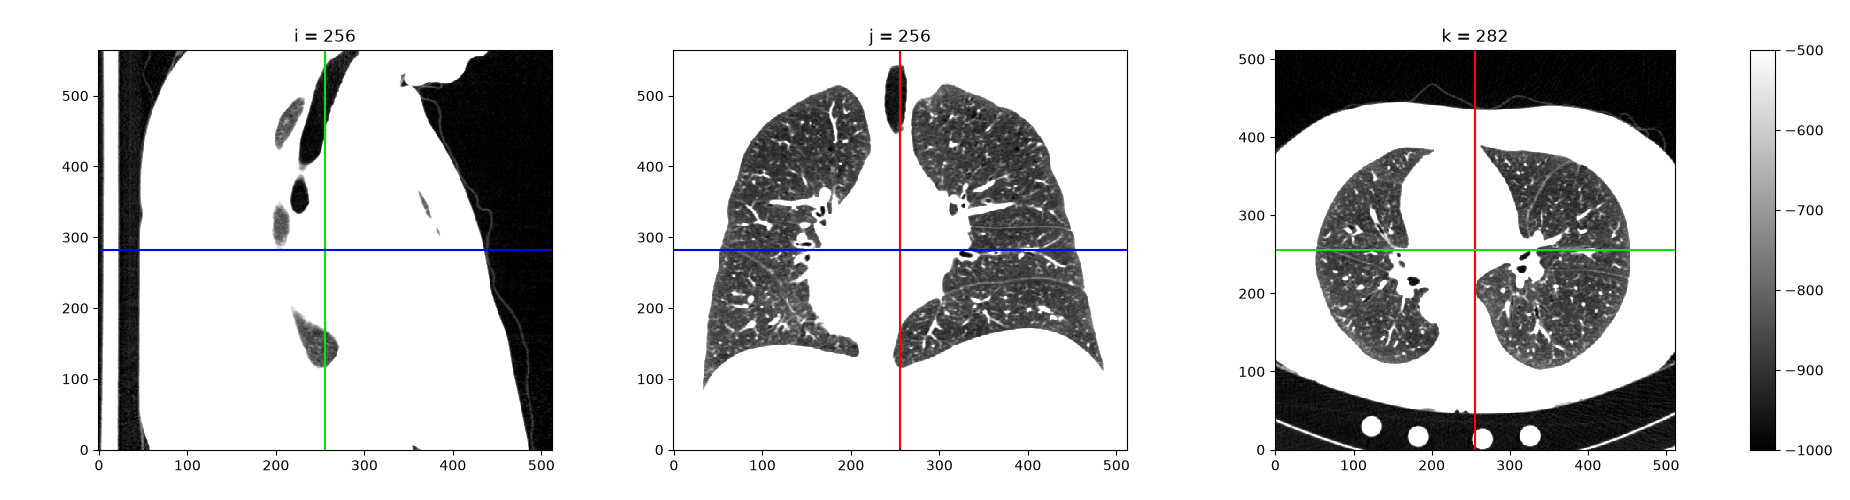

In [23]:
mpl_viz.SliceViewer(img0.get_fdata(), vox_spacing=spacing0, ax_height=4, ax_width=5, **img_kws)

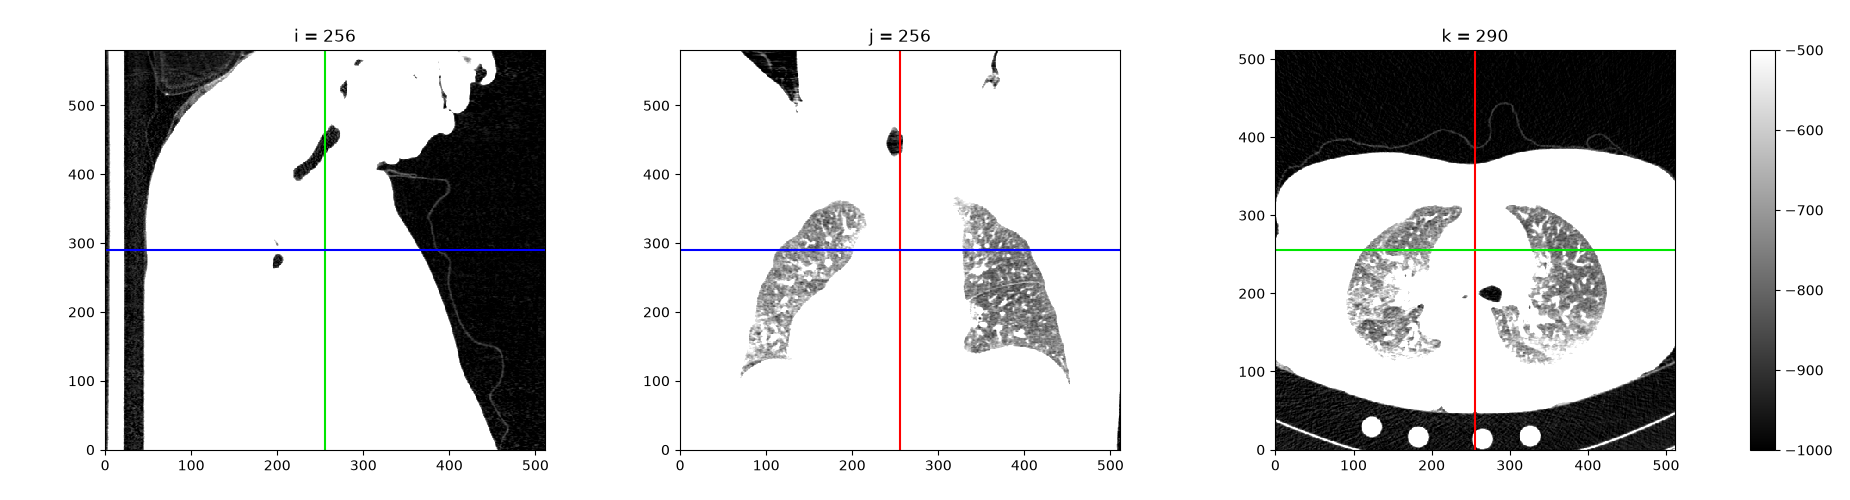

In [24]:
mpl_viz.SliceViewer(img1.get_fdata(), vox_spacing=spacing1, ax_height=4, ax_width=5,  **img_kws)

# Preprocessing tests

In [25]:
proc_config = {
    'image_resampling': {
        'spacing': (1.0, 1.0, 1.0),
        'interpolation': 'linear',
        'default_value': -1000.
    },
    'image_segmentation': {
        'tasks': [
            {
                'method': 'HU_threshold',
                'kwargs': {
                    'thresholds': {
                        'lt-950': {'type': 'absolute', 'operator': '<', 'value': -950},
                        'lt-910': {'type': 'absolute', 'operator': '<', 'value': -910},
                        'lt-850': {'type': 'absolute', 'operator': '<', 'value': -850},
                        'gt-500': {'type': 'absolute', 'operator': '>', 'value': -500},
                        'gt-200': {'type': 'absolute', 'operator': '>', 'value': -200},
                    }
                }
            },
            {
                'method': 'TotalSegmentator',
                'kwargs': {
                    'task': 'total',
                    'roi_subset': [
                        'lung_upper_lobe_right',
                        'lung_middle_lobe_right',
                        'lung_lower_lobe_right',
                        'lung_upper_lobe_left',
                        'lung_lower_lobe_left',
                    ]
                }
            },
            {
                'method': 'TotalSegmentator',
                'kwargs': {'task': 'lung_vessels'}
            },
            {
                'method': 'VisionFeature',
                'kwargs': {
                    'model': 'vista3d',
                    'results_dir': '/restricted/projectnb/batmanlab/haozhe/Lung_Mesh_Segment/data/nnUNetv2/nnUNet_results',
                }
            },
        ]
    },
    'image_registration': {
        'method': 'unigradicon',
        'kwargs': {
            'model': 'gradiconlung',
            'io_sim': 'lncc2',
            'io_iterations': 50,
            'sigma': 1,
            'loss_function_masking': True,
            'intensity_conservation_loss': True,
            'weights_root': '/restricted/projectnb/batmanlab/mragoza/lung-project/network_weights'
        }
    },
    'anatomical_regions': {
        'roi_order': [
            'lung_upper_lobe_right',
            'lung_middle_lobe_right',
            'lung_lower_lobe_right',
            'lung_upper_lobe_left',
            'lung_lower_lobe_left',
        ],
        'region_filter': {
            'min_voxels': 30,
            'keep_largest': True
        }
    },
    'material_properties': {
        'density': {
            'range': [0., 2000.],
            'terms': {
                'image':  {'offset': 1000.}
            }
        },
        'youngs_modulus': {
            'range': [0., 20000.],
            'terms': {
                'domain':        {'weight':  2000.},
                'lung_arteries': {'weight': +3000.},
                'lung_veins':    {'weight': +3000.},
                'lung_airways':  {'weight': +6000.},
                
                'lt-850':        {'weight': -1000.}, # 1000
                'lt-910':        {'weight':  -500.}, #  500
                'lt-950':        {'weight':  -250.}, #  250

                'ggo':           {'weight': +2000.}, #  4000
                'consolidation': {'weight': +4000.}, #  8000
                'nodule':        {'weight': +8000.}, # 16000 
            }
        },
        'poisson_ratio': {
            'range': [0.0, 0.5],
            'terms': {
                'domain': {'weight':  0.42},
            }
        }
    },
    'mesh_generation': {
        'use_affine_spacing': True,
        'mesh_parameters': {
            'max_facet_distance': 0.75,
            'max_cell_circumradius': 5.0,
            'lloyd': True,
            'odt': True
        }
    },
    'mesh_interpolation': {
        'displacement_key': 'u_reg',
        'interpolate_args': {}
    },
    'forward_simulation': {
        'physics_adapter': {},
        'pde_solver': {'_class': 'warp'},
        'boundary_condition': {
            'type': 'mesh_key', 'value': 'u_reg'
        },
        'output_key': 'u_fwd'
    }
}

In [81]:
project_dir = os.environ['PROJECT']

if project_dir not in sys.path:
    sys.path.append(project_dir)

#import VisionFeature

In [82]:
%autoreload
import project.preprocessing.api as api

for ex in examples[:1]:
    api.preprocess_example(ex, proc_config)

print('Done')

INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tsvf_domain.nii.gz exists; Skipping stage create_segmentation_masks
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_INSP_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_INSP_std_tsvf_domain.nii.gz exists; Skipping stage create_segmentation_masks
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_tsvf_lung_INSP.nii.gz exists; Skipping stage estimate_displacement_field
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tsvf_anat.nii.gz exists; Skipping stage label_anatomical_regio

In [44]:
import numpy as np

ex = examples[0]
img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['resampled_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['resampled_image'])
anat = project.core.fileio.load_nibabel(ex.paths['anatomical_map'])
m = anat.get_fdata() > 0

spacing0 = tuple(float(d) for d in img0.affine[:3,:3] @ np.ones(3))
print(spacing0)

spacing1 = tuple(float(d) for d in img1.affine[:3,:3] @ np.ones(3))
print(spacing1)

img0.affine

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_EXP_iso.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_INSP_iso.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_EXP_iso_tsvf_lung.nii.gz
(-1.0, 1.0, 1.0)
(-1.0, 1.0, 1.0)


array([[  -1.       ,   -0.       ,    0.       ,  167.5      ],
       [  -0.       ,    1.       ,   -0.       ,   -6.5      ],
       [   0.       ,    0.       ,    1.       , -318.3001709],
       [   0.       ,    0.       ,    0.       ,    1.       ]])

In [45]:
img_kws = dict(cmap='gray', vmin=-1024, vmax=-256)

cmap = mpl_viz.get_label_cmap(n_labels=10, select=None, include_bg=True)
mask_kws = dict(cmap=cmap, vmin=0, vmax=10)

disp_kws = dict(cmap='seismic', vmin=-20, vmax=20)

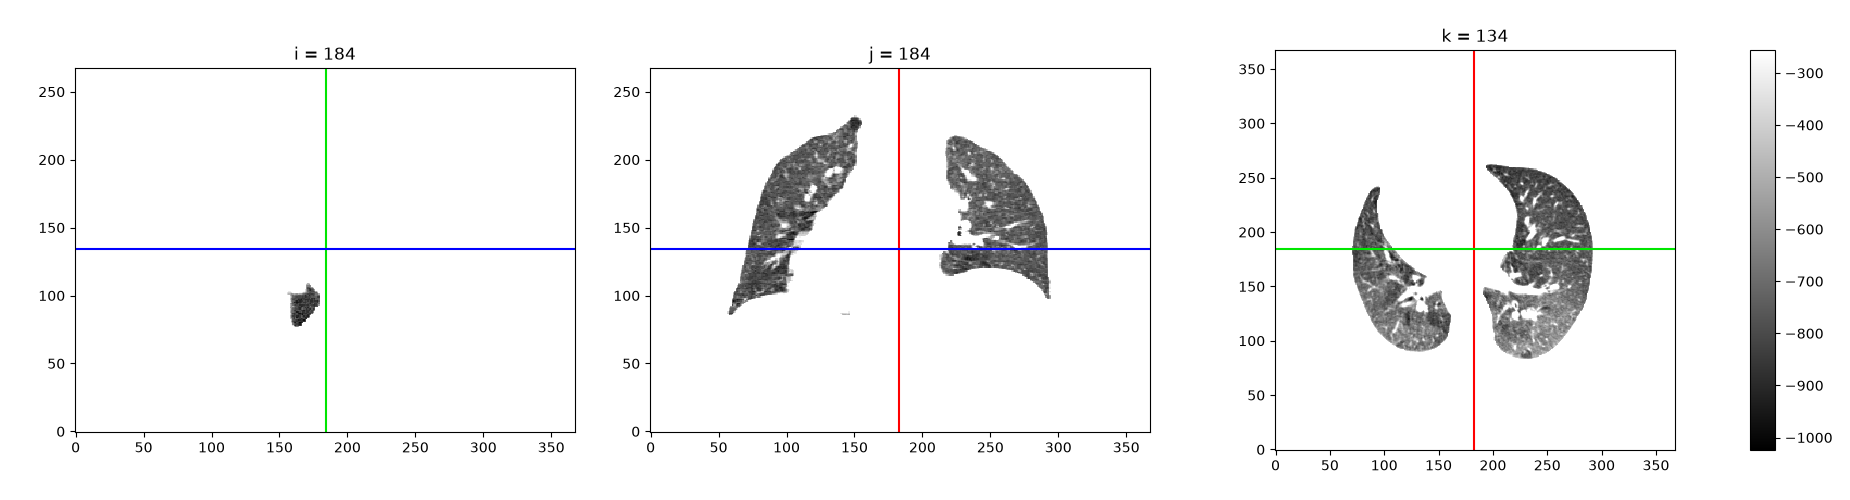

In [46]:
mpl_viz.SliceViewer(img0.get_fdata() * m, vox_spacing=spacing0, ax_height=4, ax_width=5, **img_kws)

In [47]:
mpl_viz.SliceViewer(img1.get_fdata() * m, index=(102,119,114), vox_spacing=spacing0, ax_height=4, ax_width=5, **img_kws)

-910 0.003914573321301407
-850 0.03489864967273626
-500 0.8736531120951175
-200 0.9667802238031614


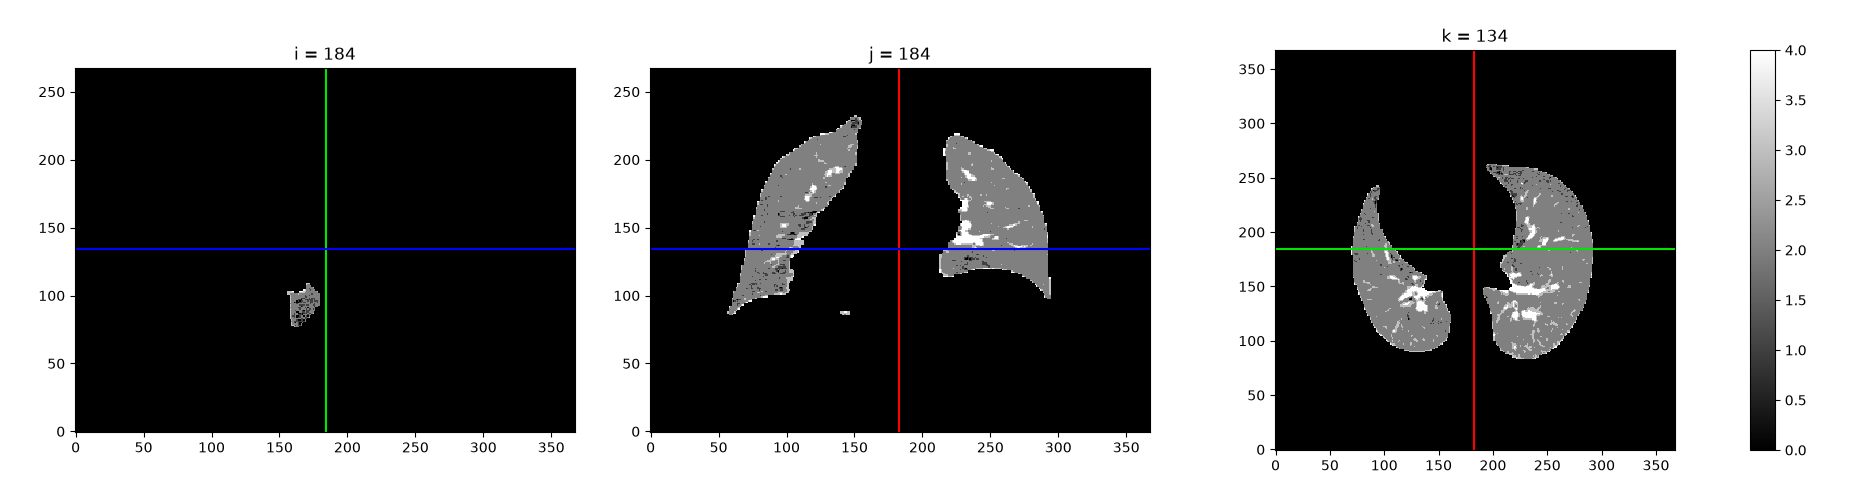

In [48]:
I = img0.get_fdata()

bins = [-910, -850, -500, -200]
#bins = np.percentile(I[m], [5, 25, 75, 95])

for b in bins:
    p = (I[m] < b).mean()
    print(b, p)

T = np.digitize(I, bins)

mpl_viz.SliceViewer(T * m, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='gray', clim=(0, len(bins)))

In [49]:
E = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'youngs_modulus.nii.gz')
nu = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'poisson_ratio.nii.gz')
rho = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'density.nii.gz')

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela/youngs_modulus.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela/poisson_ratio.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela/density.nii.gz


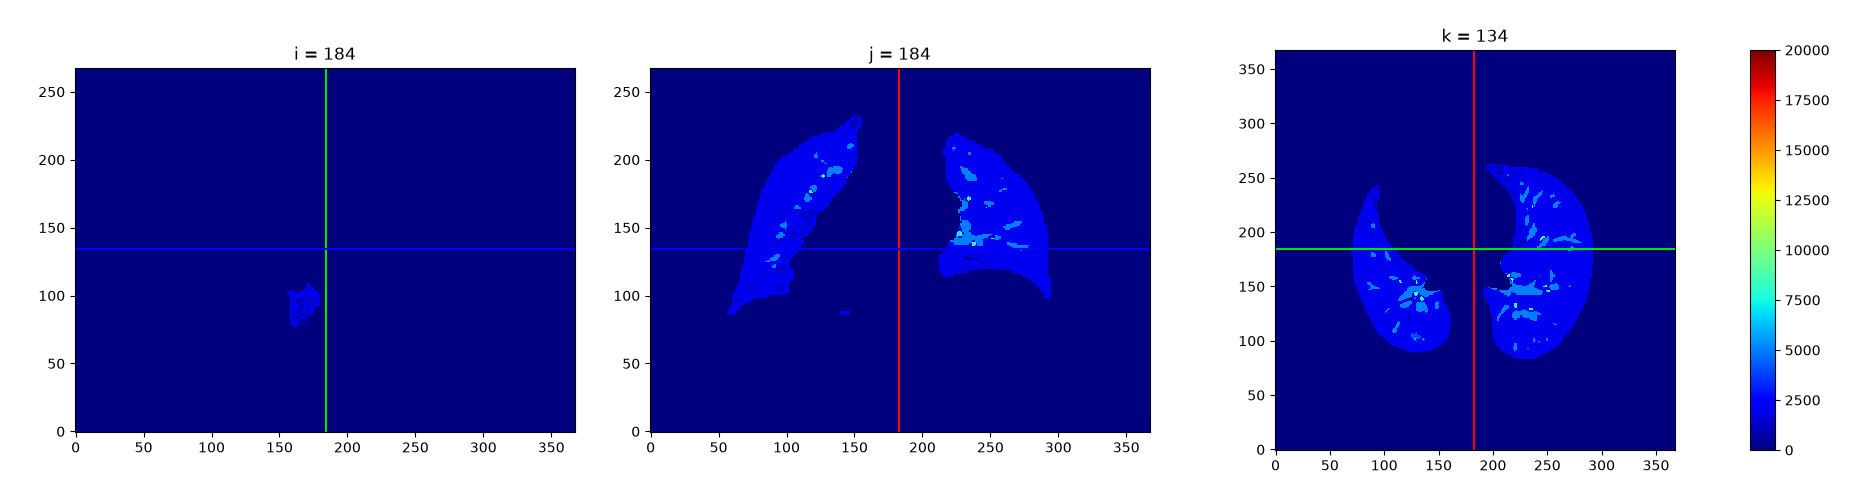

In [50]:
mpl_viz.SliceViewer(E.get_fdata(), vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='jet', clim=(0, 2e4))

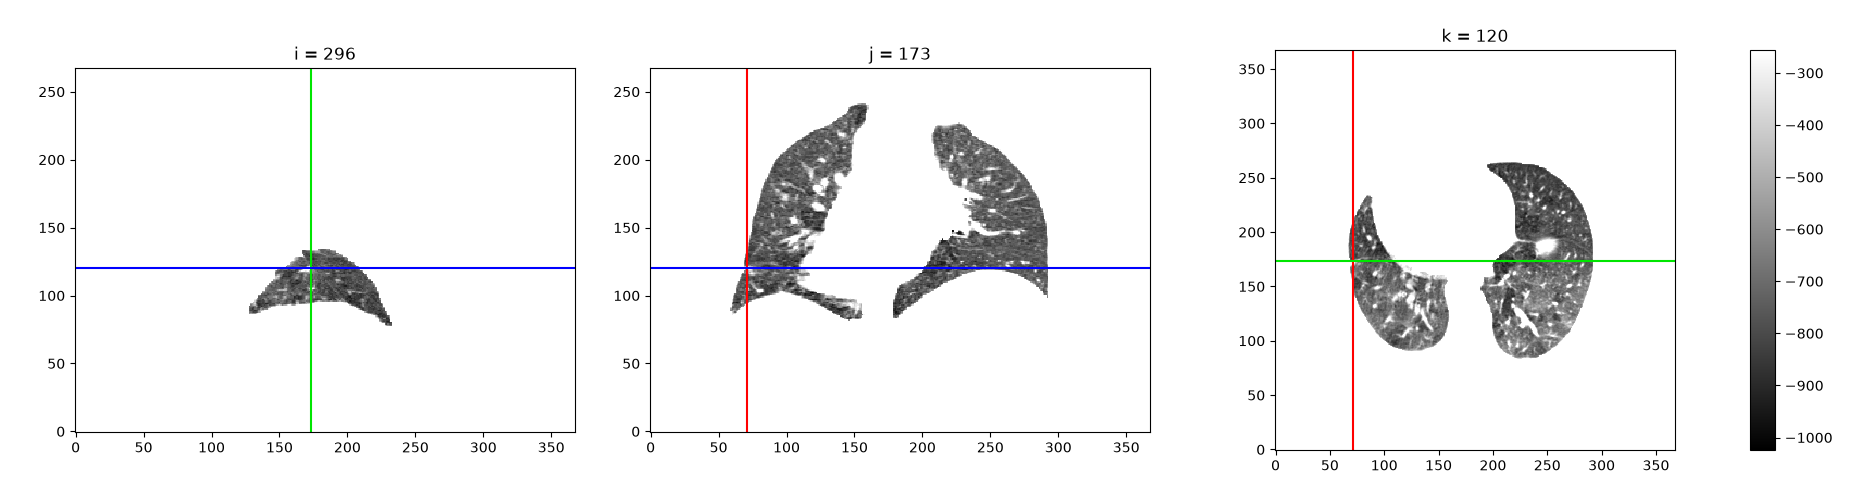

In [52]:
mpl_viz.SliceViewer(img0.get_fdata() * m, index=(296,173, 120), vox_spacing=spacing0, ax_height=4, ax_width=5, **img_kws)

In [41]:
mpl_viz.SliceViewer(nu.get_fdata(), vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='gray', clim=(0, 1))

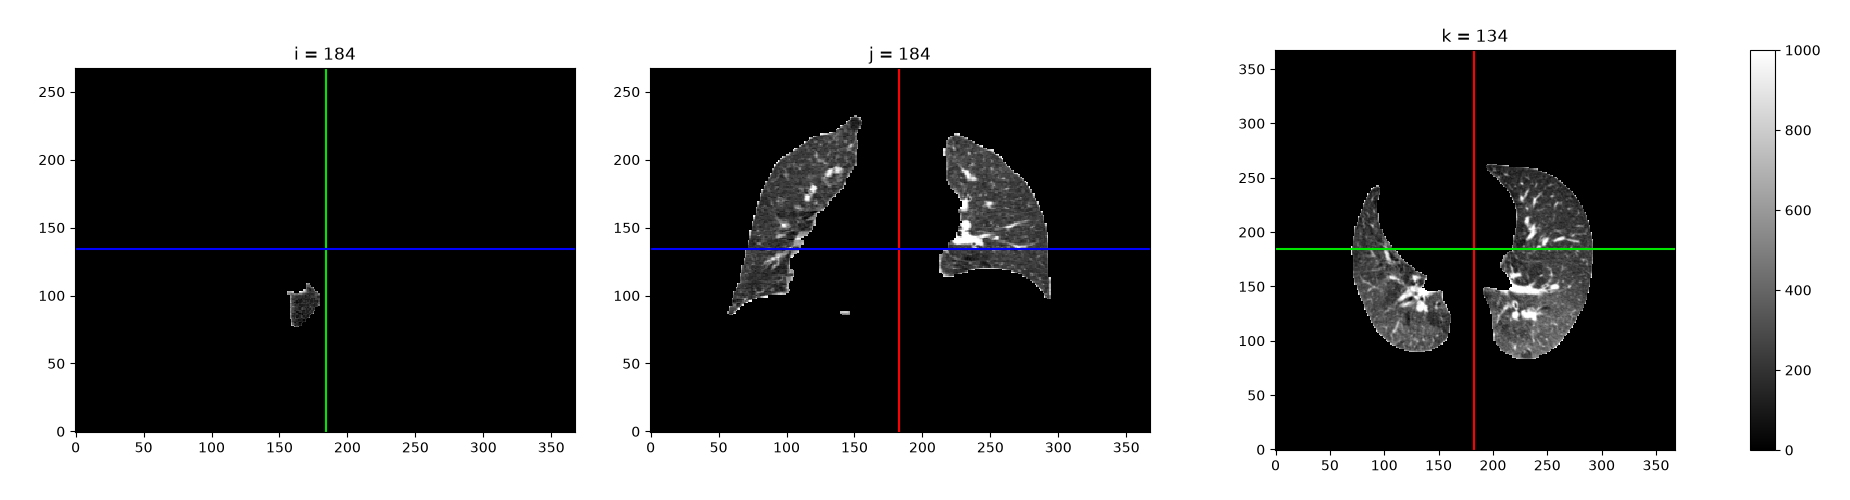

In [53]:
mpl_viz.SliceViewer(rho.get_fdata() * m, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='gray', clim=(0, 1000))

In [28]:
disp_path = str(ex.paths['disp_field'])
disp = project.core.fileio.load_nibabel(disp_path).get_fdata()

mpl_viz.SliceViewer(disp[...,0] * (mask > 0), vox_spacing=spacing0, **disp_kws)
#mpl_viz.SliceViewer(disp[...,1] * (mask > 0), vox_spacing=spacing0, **disp_kws)
#mpl_viz.SliceViewer(disp[...,2] * (mask > 0), vox_spacing=spacing0, **disp_kws)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_tsvf_lung_INSP.nii.gz


NameError: name 'mask' is not defined

In [105]:
mesh = project.core.fileio.load_meshio(ex.paths['forward_mesh'])
mesh

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_tsvf_lung_INSP_anat_pyg_mat_int_sim.xdmf


<meshio mesh object>
  Number of points: 23537
  Number of cells:
    tetra: 99716
  Point data: medit:ref, image, u_reg, E, nu, rho, u_fwd
  Cell data: medit:ref, region, image, u_reg, E, nu, rho, u_fwd

In [30]:
import project.visual.pyvista as pv_viz

In [31]:
np.arange(0, 1000, 4).shape

(250,)

2026-06-23 11:04:53.536 (1742.407s) [    1469790C6400]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


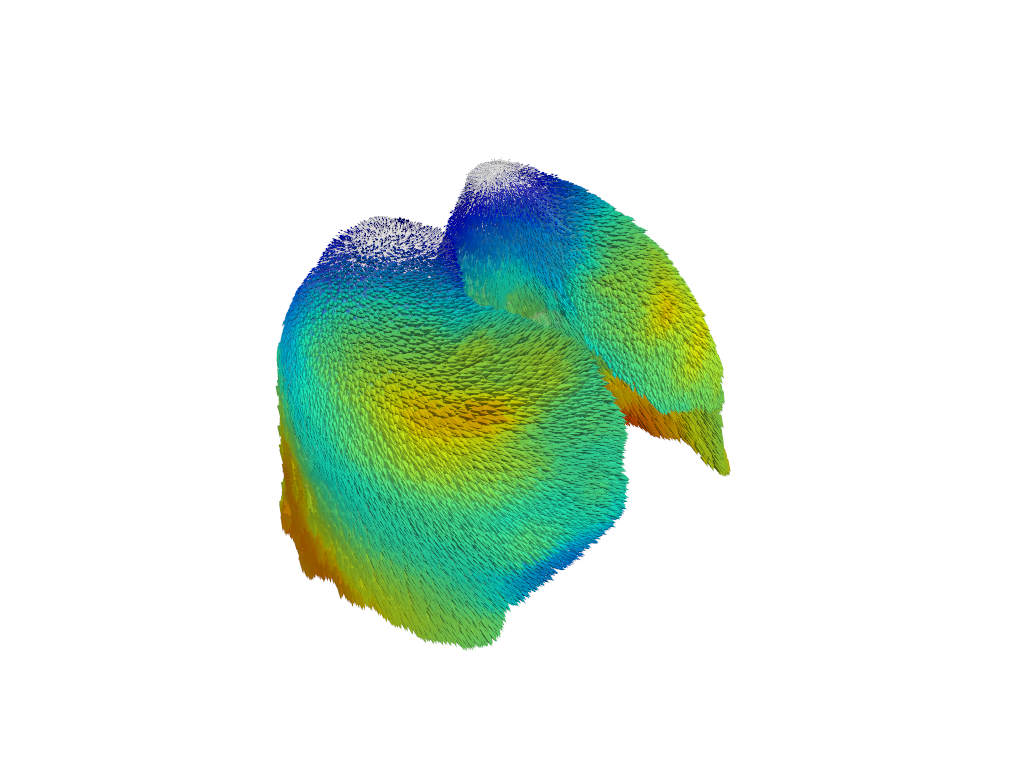

In [32]:
def show_mesh(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter()
    p.add_mesh(m, show_scalar_bar=False, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, show_scalar_bar=False, cmap='jet')
    p.show(jupyter_backend='static')

show_mesh(mesh, key='u_true')

# Optimization

In [25]:
import math

opt_config = {
    'targets': ['G', 'K'],
    'param_specs': {
        'G': {'mode': 'log10', 'mean': 3.0, 'std': 0.1},
        'K': {'mode': 'log10', 'mean': 3.7, 'std': 0.1},
        'rho': {'mode': 'log10', 'mean': 2.4, 'std': 0.1}
    },
    'physics_adapter': {
        'default_nu': 0.4,
        'default_rho': 250
    },
    'pde_solver': {
        '_class': 'WarpFEMSolver',
        'material_type': 'neohookean',
        'relative_loss': True,
        'tv_reg_weight': 1e-4, #0.001,
        'newton_steps': 100,
        'newton_alpha': 1.0,
        'newton_beta': 0.5, #math.sqrt(0.5),
        'newton_rtol': 1e-5,
        'cg_maxiter': 0, #100,
        'cg_rtol': 1e-5, #1e-4,
        'verbose': False
    },
    'optimizer': {
        '_class': 'Adam',
        'lr': 0.1,
        'global_steps': 10,
        'local_steps': 100,
        'tol': 1e-3
    },
    'initialize': {
        'num_restarts': 1,
        'noise_std': 0.1
    },
    'boundary_condition': {
        'name': 'u_true'
    }
}

In [26]:
%autoreload
import project.optimization
project.optimization.simulate_example(ex, opt_config)

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_tseg_regions_pyg_lung_INSP_int.xdmf
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_regions.nii.gz
Targets: ['G', 'K']
Warp 1.10.0.dev20251007 initialized:
   Git commit: 5ddc94f042dc7a41d22911dcff7800ab6da3be29
   CUDA Toolkit 12.8, Driver 12.6
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla V100-SXM2-32GB" (32 GiB, sm_70, mempool enabled)
   Kernel cache:
     /jet/home/mtragoza/.cache/warp/1.10.0.dev20251007


RuntimeError: Line search failed at Newton step 2

In [82]:
outputs = {}
outputs['linear'] = project.core.paths.RunOutputs(stage='opt_linear')
outputs['stvk'] = project.core.paths.RunOutputs(stage='opt_stvk')
outputs['nh'] = project.core.paths.RunOutputs(stage='opt_nh')

In [54]:
%autoreload
import project.optimization

project.optimization.optimize_example(ex, opt_config, outputs['linear'])

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_tseg_regions_pyg_lung_INSP_int.xdmf
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_regions.nii.gz
Targets: ['G', 'K']
Start optimization
Trial 1/1
Global optimization
Iteration 1 loss=2.3875e-02 (nan) grad=9.2448e-06 (1.0000e+00) norm=2.7663e+01 (nan)
Iteration 2 loss=2.3715e-02 (6.7125e-03) grad=8.9355e-06 (9.6655e-01) norm=4.0998e+01 (6.3297e-01)
Iteration 3 loss=2.3561e-02 (6.5037e-03) grad=8.6326e-06 (9.3378e-01) norm=5.6573e+01 (4.2497e-01)
Iteration 4 loss=2.3413e-02 (6.2917e-03) grad=8.3329e-06 (9.0137e-01) norm=7.2893e+01 (3.0620e-01)
Iteration 5 loss=2.3270e-02 (6.0777e-03) grad=8.0412e-06 (8.6981e-01) norm=8.9480e+01 (2.3609e-01)
Iteration 6 loss=2.3134e-02 (5.8609e-03) gr

In [83]:
import project.visual.matplotlib as mpl_viz

raster_dir = outputs['linear'].raster_dir(ex)
G_lin = project.core.fileio.load_nibabel(raster_dir / 'G_pred.nii.gz').get_fdata()
K_lin = project.core.fileio.load_nibabel(raster_dir / 'K_pred.nii.gz').get_fdata()

raster_dir = outputs['stvk'].raster_dir(ex)
G_svk = project.core.fileio.load_nibabel(raster_dir / 'G_pred.nii.gz').get_fdata()
K_svk = project.core.fileio.load_nibabel(raster_dir / 'K_pred.nii.gz').get_fdata()

Loading outputs/opt_linear/16514P/rasters/G_pred.nii.gz
Loading outputs/opt_linear/16514P/rasters/K_pred.nii.gz
Loading outputs/opt_stvk/16514P/rasters/G_pred.nii.gz
Loading outputs/opt_stvk/16514P/rasters/K_pred.nii.gz


In [ ]:
print('G - Linear')
mpl_viz.SliceViewer(G_lin, vox_spacing=spacing0, cmap='turbo', clim=(0, 2500))

In [ ]:
print('G - StVK')
mpl_viz.SliceViewer(G_svk, vox_spacing=spacing0, cmap='turbo', clim=(0, 2500))

In [ ]:
print('K - Linear')
mpl_viz.SliceViewer(K_lin, vox_spacing=spacing0, cmap='turbo', clim=(0, 1e4))

In [ ]:
print('K - StVK')
mpl_viz.SliceViewer(K_svk, vox_spacing=spacing0, cmap='turbo', clim=(0, 1e4))

# High-quality visualizations

In [121]:
print(img0.shape)
print(spacing0)
z = 134
c = 48

(368, 368, 268)
(-1.0, 1.0, 1.0)


In [122]:
img_kws = dict(cmap='gray', vmin=-1024, vmax=-384)

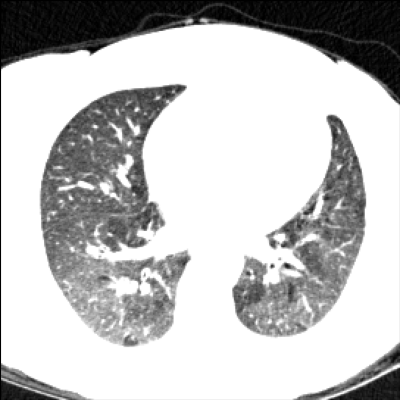

In [123]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img0.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)

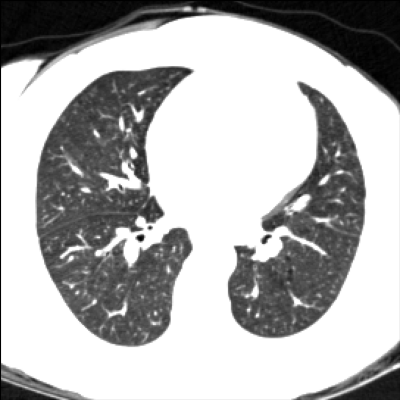

In [124]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img1.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)

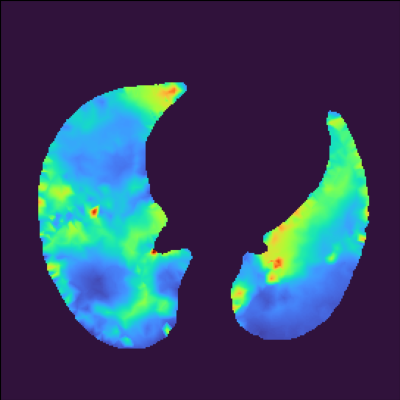

In [130]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(K_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 20000))

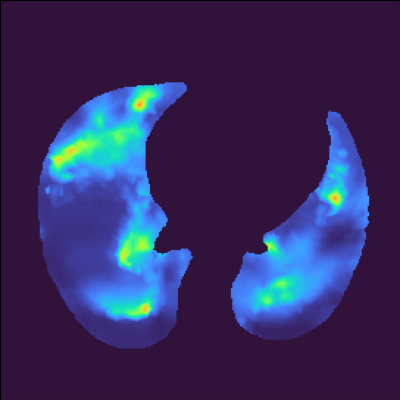

In [132]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(G_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 10000))

In [133]:
mesh = project.core.fileio.load_meshio('outputs/opt_linear/16514P/meshes/optimized.xdmf')
mesh

Loading outputs/opt_linear/16514P/meshes/optimized.xdmf


<meshio mesh object>
  Number of points: 23583
  Number of cells:
    tetra: 99939
  Point data: medit:ref, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual
  Cell data: medit:ref, region, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual

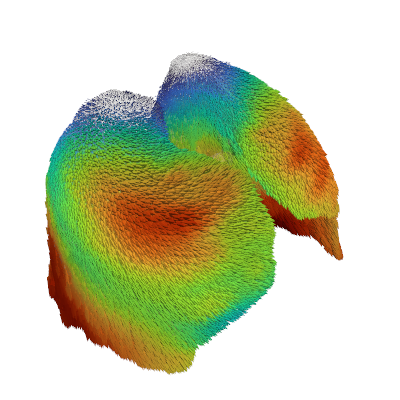

In [161]:
def show_mesh(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    p.add_mesh(m, show_scalar_bar=False, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, show_scalar_bar=False, cmap='turbo', clim=(2,24))
    p.camera.zoom(1.25)
    p.show(jupyter_backend='static')

show_mesh(mesh, key='u_true')

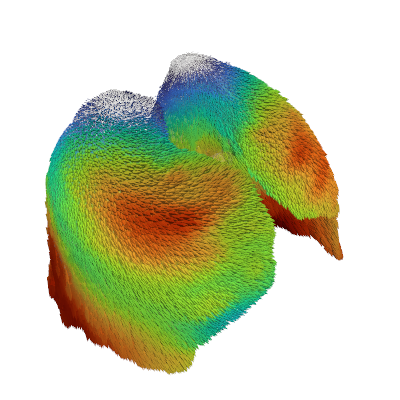

In [162]:
show_mesh(mesh, key='u_pred')

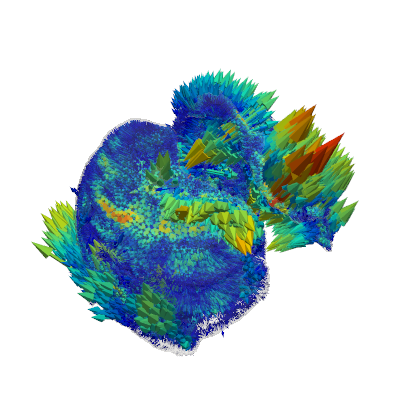

In [142]:
show_mesh(mesh, key='residual')